In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import zipfile
import os

zip_path = "/content/drive/MyDrive/final_dataset.zip"
extract_path = "/content/data"

# Create folder
os.makedirs(extract_path, exist_ok=True)

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV3Small
from tensorflow.keras import layers, models

In [4]:
img_size = 224
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

train_data = train_datagen.flow_from_directory(
    "data/final_dataset",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    "data/final_dataset",
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation'
)

Found 11956 images belonging to 3 classes.
Found 2988 images belonging to 3 classes.


In [5]:
base_model = MobileNetV3Small(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze base model (for fast training)
for layer in base_model.layers:
    layer.trainable = False

4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.BatchNormalization(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(3, activation='softmax')  # 3 classes
])

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Small (Functional)   │ (None, 7, 7, 576)      │       939,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 576)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 576)            │         2,304 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,015,667 (3.87 MB)

 Trainable params: 75,395 (294.51 KB)

 Non-trainable params: 940,272 (3.59 MB)

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=10, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=10)
]

history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=60,
    callbacks=callbacks
)

Epoch 1/60
  7/374 ━━━━━━━━━━━━━━━━━━━━ 1:47 293ms/step - accuracy: 0.4556 - loss: 1.0336

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


374/374 ━━━━━━━━━━━━━━━━━━━━ 218s 541ms/step - accuracy: 0.6502 - loss: 0.7024 - val_accuracy: 0.4940 - val_loss: 1.0143 - learning_rate: 0.0010
Epoch 2/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 233s 492ms/step - accuracy: 0.6953 - loss: 0.6317 - val_accuracy: 0.7242 - val_loss: 0.5991 - learning_rate: 0.0010
Epoch 3/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 201s 490ms/step - accuracy: 0.7088 - loss: 0.6053 - val_accuracy: 0.7540 - val_loss: 0.5479 - learning_rate: 0.0010
Epoch 4/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 185s 494ms/step - accuracy: 0.7225 - loss: 0.5832 - val_accuracy: 0.7507 - val_loss: 0.5406 - learning_rate: 0.0010
Epoch 5/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 186s 496ms/step - accuracy: 0.7264 - loss: 0.5708 - val_accuracy: 0.7664 - val_loss: 0.5404 - learning_rate: 0.0010
Epoch 6/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 183s 490ms/step - accuracy: 0.7372 - loss: 0.5571 - val_accuracy: 0.7641 - val_loss: 0.5278 - learning_rate: 0.0010
Epoch 7/60
374/374 ━━━━━━━━━━━━━━━━━━━━ 193s 516ms/step - accuracy: 0.7357 

In [9]:
model.save("mosquito_model_mobilenet.h5")

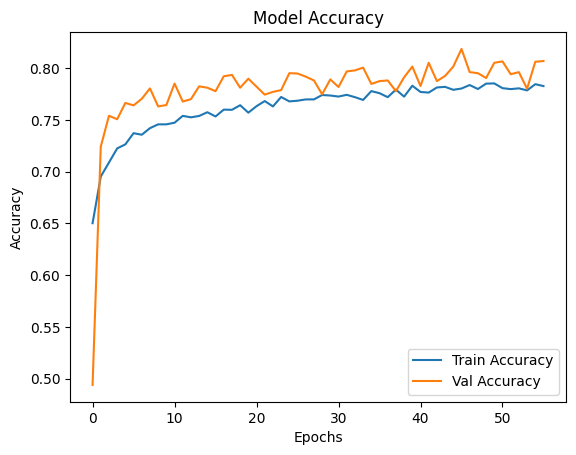

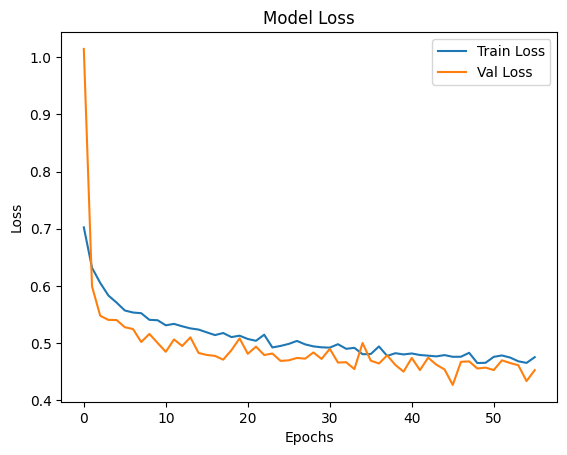

In [10]:
import matplotlib.pyplot as plt

# Accuracy
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [11]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

print("Confusion Matrix:")
print(confusion_matrix(val_data.classes, y_pred))

print("\nClassification Report:")
print(classification_report(val_data.classes, y_pred))

94/94 ━━━━━━━━━━━━━━━━━━━━ 48s 421ms/step
Confusion Matrix:
[[289 383 316]
 [302 362 336]
 [317 354 329]]

Classification Report:
              precision    recall  f1-score   support

           0       0.32      0.29      0.30       988
           1       0.33      0.36      0.34      1000
           2       0.34      0.33      0.33      1000

    accuracy                           0.33      2988
   macro avg       0.33      0.33      0.33      2988
weighted avg       0.33      0.33      0.33      2988



94/94 ━━━━━━━━━━━━━━━━━━━━ 37s 385ms/step


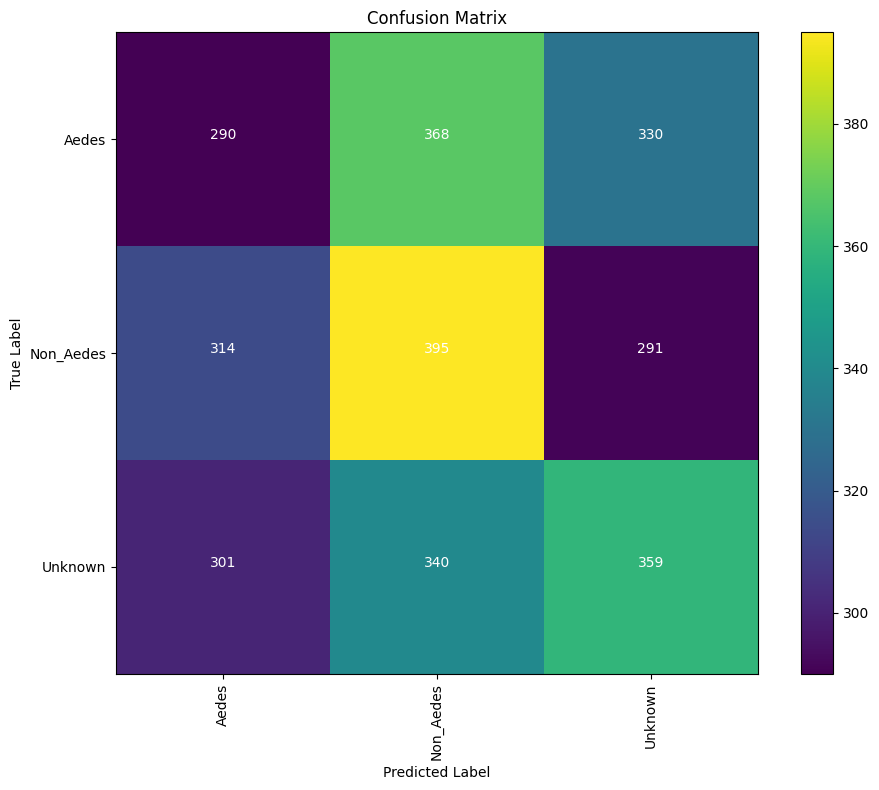

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Step 1: Predict
Y_pred = model.predict(val_data)
y_pred = np.argmax(Y_pred, axis=1)

# Step 2: True labels
y_true = val_data.classes

# Step 3: Class names
class_names = list(val_data.class_indices.keys())

# Step 4: Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Step 5: Plot
plt.figure(figsize=(10, 8))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90)
plt.yticks(tick_marks, class_names)

# Step 6: Add values inside boxes
thresh = cm.max() / 2
for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j],
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

In [16]:
model.save("mosquito_model.keras")

Model loaded successfully!


Saving 33.jpeg to 33.jpeg

Image: 33.jpeg


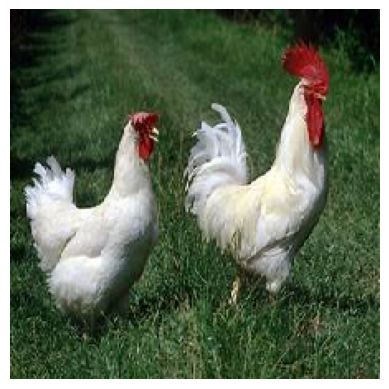

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step

🔍 Predicted Class: Unknown
📊 Confidence: 0.99879885


In [21]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing import image
from google.colab import files
import matplotlib.pyplot as plt
from PIL import Image

# 1. Load model
model = tf.keras.models.load_model("/content/mosquito_model.keras")

print("Model loaded successfully!")

# 2. Upload image
uploaded = files.upload()

# 3. IMPORTANT: define class labels (same order as training)
class_labels = list(train_data.class_indices.keys())

# 4. Prediction function
def predict_image(img_path):
    img = image.load_img(img_path, target_size=(224, 224))

    # show image
    plt.imshow(img)
    plt.axis("off")
    plt.show()

    # preprocess
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # predict
    prediction = model.predict(img_array)
    class_index = np.argmax(prediction)

    print("\n🔍 Predicted Class:", class_labels[class_index])
    print("📊 Confidence:", np.max(prediction))

# 5. Run for uploaded image
for file_name in uploaded.keys():
    print("\nImage:", file_name)
    predict_image(file_name)